In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display


def set_seed(seed=0):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


device: cpu


In [2]:
# Ground-truth 2D simulator

def simulate_2d_free_flight(x0, v, dt, T):
    """
    x0: (2,)  initial position
    v:  (2,)  constant velocity
    dt: float
    T:  int steps
    returns positions: (T+1, 2)
    """
    x = np.zeros((T + 1, 2), dtype=np.float32)
    x[0] = x0
    for t in range(T):
        x[t + 1] = x[t] + v * dt
    return x


# Dataset: one-step pairs in 2D
# input:  [x_t, y_t, vx_t, vy_t, dt]
# target: [x_{t+1}, y_{t+1}, vx_{t+1}, vy_{t+1}]
class OneStepDataset2D(Dataset):
    def __init__(self, N=80000, dt=0.05, x_range=(-2.0, 2.0), v_range=(-2.0, 2.0)):
        self.dt = float(dt)

        x_t = np.random.uniform(x_range[0], x_range[1], size=(N, 2)).astype(np.float32)
        v_t = np.random.uniform(v_range[0], v_range[1], size=(N, 2)).astype(np.float32)
        dtc = np.full((N, 1), self.dt, dtype=np.float32)

        x_tp1 = x_t + v_t * self.dt

        v_tp1 = v_t

        self.X = np.concatenate([x_t, v_t, dtc], axis=1)  # (N, 5)
        self.Y = np.concatenate([x_tp1, v_tp1], axis=1)  # (N, 4)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, i):
        return torch.from_numpy(self.X[i]), torch.from_numpy(self.Y[i])


In [3]:
# Data generation / dataset build

dt = 0.05
dataset = OneStepDataset2D(N=100000, dt=dt, x_range=(-2, 2), v_range=(-2, 2))
N = len(dataset)
n_train = int(0.8 * N)
train_ds, test_ds = torch.utils.data.random_split(dataset, [n_train, N - n_train])

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=1024, shuffle=False)

print(f"dataset size: {N} | train: {len(train_ds)} | test: {len(test_ds)} | dt: {dt}")

print("X shape:", dataset.X.shape, "Y shape:", dataset.Y.shape)
assert dataset.Y.shape[1] == 4, f"Expected Y dim 4, got {dataset.Y.shape}"


dataset size: 100000 | train: 80000 | test: 20000 | dt: 0.05
X shape: (100000, 5) Y shape: (100000, 4)


In [4]:
# Architectures to fit

class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=128, depth=3, act="tanh"):
        super().__init__()
        layers = []
        d = in_dim
        for _ in range(depth):
            layers.append(nn.Linear(d, hidden))
            if act == "tanh":
                layers.append(nn.Tanh())
            elif act == "relu":
                layers.append(nn.ReLU())
            else:
                raise ValueError("act must be 'tanh' or 'relu'")
            d = hidden
        layers.append(nn.Linear(d, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class LinearNextState2D(nn.Module):
    # Learned linear transition: s_{t+1} = W [x_t, v_t, dt] + b
    def __init__(self):
        super().__init__()
        self.lin = nn.Linear(5, 4)

    def forward(self, x_t, v_t, dt):
        inp = torch.cat([x_t, v_t, dt], dim=1)
        return self.lin(inp)


class ResidualNextState2D(nn.Module):
    # state_{t+1} = state_t + g(x_t, v_t, dt)
    def __init__(self, hidden=128, depth=3):
        super().__init__()
        self.g = MLP(in_dim=5, out_dim=4, hidden=hidden, depth=depth, act="tanh")

    def forward(self, x_t, v_t, dt):
        inp = torch.cat([x_t, v_t, dt], dim=1)
        dstate = self.g(inp)
        state_t = torch.cat([x_t, v_t], dim=1)
        return state_t + dstate


class PhysicsResidualNextState2D(nn.Module):
    # state_{t+1} = physics_baseline(x_t, v_t, dt) + g(x_t, v_t, dt)
    # physics baseline: x_{t+1}=x_t+v_t*dt, v_{t+1}=v_t
    def __init__(self, hidden=128, depth=3):
        super().__init__()
        self.g = MLP(in_dim=5, out_dim=4, hidden=hidden, depth=depth, act="tanh")

    def forward(self, x_t, v_t, dt):
        inp = torch.cat([x_t, v_t, dt], dim=1)
        dstate = self.g(inp)
        x_phys = x_t + v_t * dt
        v_phys = v_t
        state_phys = torch.cat([x_phys, v_phys], dim=1)
        return state_phys + dstate



In [5]:
# Training + rollout utilities

def train_model(model, train_loader, test_loader, epochs=100, lr=1e-3):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    history = {"train": [], "test": []}

    for ep in range(1, epochs + 1):
        model.train()
        tr = 0.0
        for X, Y in train_loader:
            X, Y = X.to(device), Y.to(device)
            x_t = X[:, 0:2]
            v_t = X[:, 2:4]
            dt_batch = X[:, 4:5]
            pred = model(x_t, v_t, dt_batch)
            loss = loss_fn(pred, Y)

            opt.zero_grad()
            loss.backward()
            opt.step()
            tr += loss.item() * X.size(0)
        tr /= len(train_loader.dataset)

        model.eval()
        te = 0.0
        with torch.no_grad():
            for X, Y in test_loader:
                X, Y = X.to(device), Y.to(device)
                x_t = X[:, 0:2]
                v_t = X[:, 2:4]
                dt_batch = X[:, 4:5]
                pred = model(x_t, v_t, dt_batch)
                loss = loss_fn(pred, Y)
                te += loss.item() * X.size(0)
        te /= len(test_loader.dataset)

        history["train"].append(float(tr))
        history["test"].append(float(te))

        if ep == 1 or ep % 2 == 0 or ep == epochs:
            print(f"epoch {ep:02d} | train MSE {tr:.3e} | test MSE {te:.3e}")

    return model, history


def train_model_multistep(model, train_loader, test_loader, horizon=20, epochs=100, lr=1e-3):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    history = {"train": [], "test": []}
    H = int(horizon)

    def batch_multistep_loss(X):
        x0 = X[:, 0:2]
        v0 = X[:, 2:4]
        dt_batch = X[:, 4:5]

        x_pred = x0
        v_pred = v0
        loss = 0.0

        for k in range(1, H + 1):
            state_pred = model(x_pred, v_pred, dt_batch)
            x_pred = state_pred[:, 0:2]
            v_pred = state_pred[:, 2:4]

            x_true_k = x0 + v0 * dt_batch * k
            state_true_k = torch.cat([x_true_k, v0], dim=1)
            loss = loss + loss_fn(state_pred, state_true_k)

        return loss / H

    for ep in range(1, epochs + 1):
        model.train()
        tr = 0.0
        for X, _ in train_loader:
            X = X.to(device)
            loss = batch_multistep_loss(X)

            opt.zero_grad()
            loss.backward()
            opt.step()
            tr += loss.item() * X.size(0)
        tr /= len(train_loader.dataset)

        model.eval()
        te = 0.0
        with torch.no_grad():
            for X, _ in test_loader:
                X = X.to(device)
                loss = batch_multistep_loss(X)
                te += loss.item() * X.size(0)
        te /= len(test_loader.dataset)

        history["train"].append(float(tr))
        history["test"].append(float(te))

        if ep == 1 or ep % 2 == 0 or ep == epochs:
            print(f"epoch {ep:02d} | train multi-step MSE {tr:.3e} | test multi-step MSE {te:.3e}")

    return model, history


@torch.no_grad()
def rollout_state_2d(model, x0, v0, dt, T):
    model.eval()
    x_t = torch.tensor(x0.reshape(1, 2), dtype=torch.float32, device=device)
    v_t = torch.tensor(v0.reshape(1, 2), dtype=torch.float32, device=device)
    dt_t = torch.tensor([[dt]], dtype=torch.float32, device=device)

    states = [np.concatenate([x0, v0]).astype(np.float32)]
    for _ in range(T):
        state_next = model(x_t, v_t, dt_t)
        state_np = state_next.detach().cpu().numpy().reshape(4).astype(np.float32)
        states.append(state_np)
        x_t = torch.tensor(state_np[:2].reshape(1, 2), dtype=torch.float32, device=device)
        v_t = torch.tensor(state_np[2:].reshape(1, 2), dtype=torch.float32, device=device)
    return np.stack(states, axis=0)



In [6]:
# Train models: linear vs residual variants

EPOCHS = 10
MULTISTEP_HORIZON = 20

print("\nTraining LINEAR model (one-step loss)")
linear_model = LinearNextState2D()
linear_model, hist_linear = train_model(
    linear_model,
    train_loader,
    test_loader,
    epochs=EPOCHS,
    lr=1e-3,
)

print("\nTraining RESIDUAL model (one-step loss)")
resid_onestep = ResidualNextState2D(hidden=128, depth=3)
resid_onestep, hist_resid_onestep = train_model(
    resid_onestep,
    train_loader,
    test_loader,
    epochs=EPOCHS,
    lr=1e-3,
)

print(f"\nTraining RESIDUAL model (multi-step loss, horizon={MULTISTEP_HORIZON})")
resid_multistep = ResidualNextState2D(hidden=128, depth=3)
resid_multistep, hist_resid_multistep = train_model_multistep(
    resid_multistep,
    train_loader,
    test_loader,
    horizon=MULTISTEP_HORIZON,
    epochs=EPOCHS,
    lr=1e-3,
)

print("\nTraining PHYSICS-RESIDUAL model (one-step loss)")
phys_resid_onestep = PhysicsResidualNextState2D(hidden=128, depth=3)
phys_resid_onestep, hist_phys_resid_onestep = train_model(
    phys_resid_onestep,
    train_loader,
    test_loader,
    epochs=EPOCHS,
    lr=1e-3,
)




Training RESIDUAL model (one-step loss)
epoch 01 | train MSE 2.789e-04 | test MSE 6.543e-06
epoch 02 | train MSE 4.675e-06 | test MSE 3.508e-06
epoch 04 | train MSE 1.911e-06 | test MSE 1.955e-06
epoch 06 | train MSE 2.666e-06 | test MSE 1.193e-06
epoch 08 | train MSE 1.425e-06 | test MSE 8.479e-07
epoch 10 | train MSE 2.344e-06 | test MSE 1.436e-06

Training RESIDUAL model (multi-step loss, horizon=20)
epoch 01 | train multi-step MSE 9.446e-02 | test multi-step MSE 1.421e-03
epoch 02 | train multi-step MSE 8.984e-04 | test multi-step MSE 6.038e-04
epoch 04 | train multi-step MSE 3.370e-04 | test multi-step MSE 3.554e-04
epoch 06 | train multi-step MSE 2.539e-04 | test multi-step MSE 5.676e-04
epoch 08 | train multi-step MSE 3.016e-04 | test multi-step MSE 1.238e-04
epoch 10 | train multi-step MSE 2.380e-04 | test multi-step MSE 8.984e-05

Training PHYSICS-RESIDUAL model (one-step loss)
epoch 01 | train MSE 1.882e-04 | test MSE 3.359e-06
epoch 02 | train MSE 1.960e-06 | test MSE 1.715

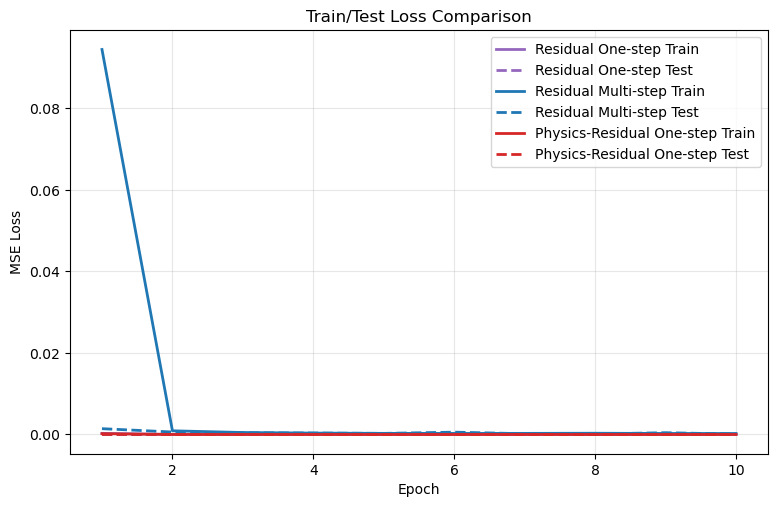

In [7]:
# Train/Test loss curves

epochs_arr = np.arange(1, len(hist_resid_onestep["train"]) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_arr, hist_linear["train"], color="tab:orange", lw=2, label="Linear Train")
plt.plot(epochs_arr, hist_linear["test"], color="tab:orange", lw=2, ls="--", label="Linear Test")
plt.plot(epochs_arr, hist_resid_onestep["train"], color="tab:purple", lw=2, label="Residual One-step Train")
plt.plot(epochs_arr, hist_resid_onestep["test"], color="tab:purple", lw=2, ls="--", label="Residual One-step Test")
plt.plot(epochs_arr, hist_resid_multistep["train"], color="tab:blue", lw=2, label="Residual Multi-step Train")
plt.plot(epochs_arr, hist_resid_multistep["test"], color="tab:blue", lw=2, ls="--", label="Residual Multi-step Test")
plt.plot(epochs_arr, hist_phys_resid_onestep["train"], color="tab:red", lw=2, label="Physics-Residual One-step Train")
plt.plot(epochs_arr, hist_phys_resid_onestep["test"], color="tab:red", lw=2, ls="--", label="Physics-Residual One-step Test")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Train/Test Loss Comparison")
plt.grid(True, alpha=0.3)
plt.legend(loc="best")
plt.show()



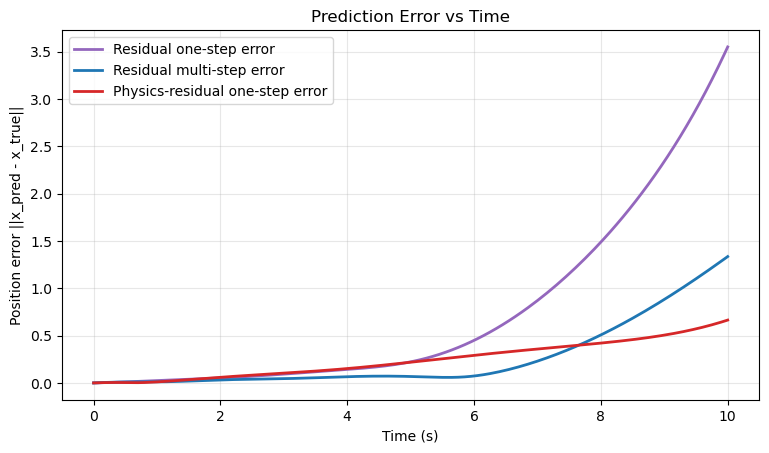

In [8]:
# Rollout + error vs time

T = 200
x0 = np.array([-1.2, 0.7], dtype=np.float32)
v0 = np.array([1.1, -0.4], dtype=np.float32)

gt = simulate_2d_free_flight(x0, v0, dt, T)
linear_state = rollout_state_2d(linear_model, x0, v0, dt, T)
resid_onestep_state = rollout_state_2d(resid_onestep, x0, v0, dt, T)
resid_multistep_state = rollout_state_2d(resid_multistep, x0, v0, dt, T)
phys_resid_onestep_state = rollout_state_2d(phys_resid_onestep, x0, v0, dt, T)

linear_pred = linear_state[:, :2]
resid_onestep_pred = resid_onestep_state[:, :2]
resid_multistep_pred = resid_multistep_state[:, :2]
phys_resid_onestep_pred = phys_resid_onestep_state[:, :2]

time = np.arange(T + 1) * dt
err_linear = np.linalg.norm(linear_pred - gt, axis=1)
err_resid_onestep = np.linalg.norm(resid_onestep_pred - gt, axis=1)
err_resid_multistep = np.linalg.norm(resid_multistep_pred - gt, axis=1)
err_phys_resid_onestep = np.linalg.norm(phys_resid_onestep_pred - gt, axis=1)

plt.figure(figsize=(10, 5))
plt.plot(time, err_linear, color="tab:orange", lw=2, label="Linear error")
plt.plot(time, err_resid_onestep, color="tab:purple", lw=2, label="Residual one-step error")
plt.plot(time, err_resid_multistep, color="tab:blue", lw=2, label="Residual multi-step error")
plt.plot(time, err_phys_resid_onestep, color="tab:red", lw=2, label="Physics-residual one-step error")
plt.xlabel("Time (s)")
plt.ylabel("Position error ||x_pred - x_true||")
plt.title("Prediction Error vs Time")
plt.grid(True, alpha=0.3)
plt.legend(loc="best")
plt.show()



Initial position perturbation: [ 0.02 -0.01]
Initial velocity perturbation: [0. 0.]
Final separation: 0.022361084818840027


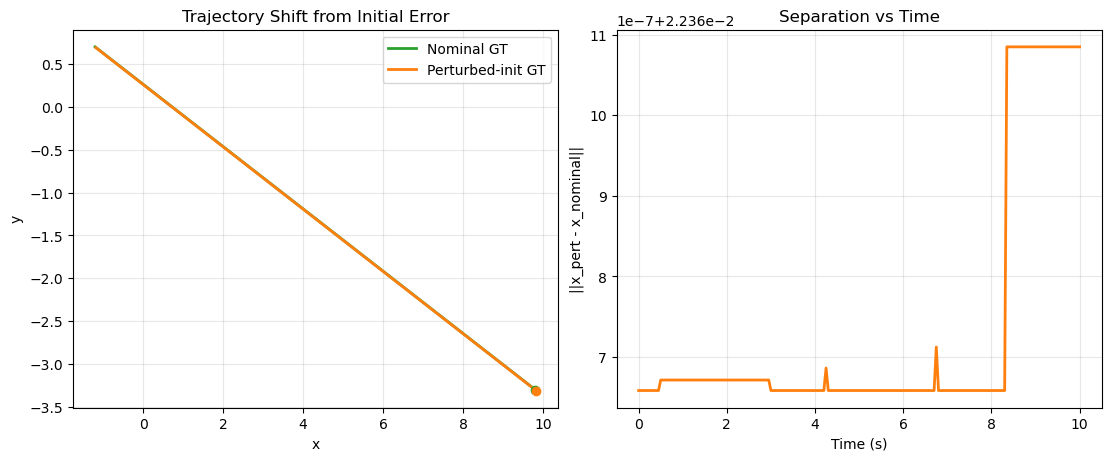

In [ ]:
# Ground-truth sensitivity to small initial-condition error

# Small perturbation to initial state
pos_eps = np.array([0.0, 0.0], dtype=np.float32)
vel_eps = np.array([0.02, -0.01], dtype=np.float32)

x0_pert = x0 + pos_eps
v0_pert = v0 + vel_eps

gt_nominal = simulate_2d_free_flight(x0, v0, dt, T)
gt_perturbed = simulate_2d_free_flight(x0_pert, v0_pert, dt, T)

sep = np.linalg.norm(gt_perturbed - gt_nominal, axis=1)
time = np.arange(T + 1) * dt

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

# Trajectory view
axes[0].plot(gt_nominal[:, 0], gt_nominal[:, 1], lw=2, color="tab:green", label="Nominal GT")
axes[0].plot(gt_perturbed[:, 0], gt_perturbed[:, 1], lw=2, color="tab:orange", label="Perturbed-init GT")
axes[0].plot([gt_nominal[-1, 0]], [gt_nominal[-1, 1]], marker="o", color="tab:green")
axes[0].plot([gt_perturbed[-1, 0]], [gt_perturbed[-1, 1]], marker="o", color="tab:orange")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("Trajectory Shift from Initial Error")
axes[0].grid(alpha=0.3)
axes[0].legend(loc="best")

# Separation vs time
axes[1].plot(time, sep, lw=2, color="tab:orange")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("||x_pert - x_nominal||")
axes[1].set_title("Separation vs Time")
axes[1].grid(alpha=0.3)

print("Initial position perturbation:", pos_eps)
print("Initial velocity perturbation:", vel_eps)
print("Final separation:", float(sep[-1]))
plt.show()



In [10]:
# Interactive slider visualization (models vs nominal ground truth)

all_xy = np.vstack([gt, linear_pred, resid_onestep_pred, resid_multistep_pred, phys_resid_onestep_pred])
pad = 0.5
xmin, ymin = all_xy.min(axis=0) - pad
xmax, ymax = all_xy.max(axis=0) + pad


def plot_frame(k):
    k = int(k)
    gt_xy = gt[: k + 1]
    lin_xy = linear_pred[: k + 1]
    one_xy = resid_onestep_pred[: k + 1]
    multi_xy = resid_multistep_pred[: k + 1]
    phys_xy = phys_resid_onestep_pred[: k + 1]

    fig, ax = plt.subplots(1, 1, figsize=(8, 6), constrained_layout=True)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"Ground Truth vs Learned Models | t = {k * dt:.2f}s (frame {k}/{T})")

    ax.plot(gt_xy[:, 0], gt_xy[:, 1], lw=2, color="tab:green", label="Ground Truth")
    ax.plot([gt_xy[-1, 0]], [gt_xy[-1, 1]], marker="o", markersize=6, color="tab:green")

    ax.plot(lin_xy[:, 0], lin_xy[:, 1], lw=2, color="tab:orange", label="Linear")
    ax.plot([lin_xy[-1, 0]], [lin_xy[-1, 1]], marker="o", markersize=6, color="tab:orange")

    ax.plot(one_xy[:, 0], one_xy[:, 1], lw=2, color="tab:purple", label="Residual One-step")
    ax.plot([one_xy[-1, 0]], [one_xy[-1, 1]], marker="o", markersize=6, color="tab:purple")

    ax.plot(multi_xy[:, 0], multi_xy[:, 1], lw=2, color="tab:blue", label="Residual Multi-step")
    ax.plot([multi_xy[-1, 0]], [multi_xy[-1, 1]], marker="o", markersize=6, color="tab:blue")

    ax.plot(phys_xy[:, 0], phys_xy[:, 1], lw=2, color="tab:red", label="Physics-Residual One-step")
    ax.plot([phys_xy[-1, 0]], [phys_xy[-1, 1]], marker="o", markersize=6, color="tab:red")

    ax.legend(loc="best")
    plt.show()


frame_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=T,
    step=1,
    description="frame",
    continuous_update=False,
)
out = widgets.interactive_output(plot_frame, {"k": frame_slider})
display(frame_slider, out)



IntSlider(value=0, continuous_update=False, description='frame', max=200)

Output()